# Beta Has a Half-Life \U0001F4C9
### The number is printed to two decimals. Perhaps one of them is real.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

A beta appears on every risk report, in every cost-of-capital calculation, behind every hedge
ratio. It arrives without a standard error and without an expiry date. This study supplies both.

> \U0001F4D3 **This is the plain-language layer.** The variance decomposition, the forecast
> horse race and the constant-beta control are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does last year's beta predict this year's? | Partly. |
| How long before it is half stale? | Around a year and a half. |
| Is beta really that unstable? | No — the *estimate* is. |
| Should you shrink it toward 1? | Yes, and by about a third. |

## 1 · One company's beta, year by year

In [2]:
from betahalflife import data, strategy as st

px = data.load_prices()
cols = [c for c in (data.MARKET,) + data.NAMES if c in px.columns]
R = px[cols].pct_change().dropna()
betas = st.rolling_betas(R, data.MARKET, 252, 252)
lf = st.long_form(betas)
print(f"as-of {data.AS_OF} | {len(cols)-1} names, {len(R):,} sessions from "
      f"{R.index[0].date()}")
print(f"{len(betas)} non-overlapping annual windows -> {len(lf):,} beta estimates")
print(f"mean beta {lf['beta'].mean():.3f}, mean standard error {lf['se'].mean():.4f}")

as-of 2026-06-30 | 40 names, 4,146 sessions from 2010-01-05
16 non-overlapping annual windows -> 640 beta estimates
mean beta 0.952, mean standard error 0.0885


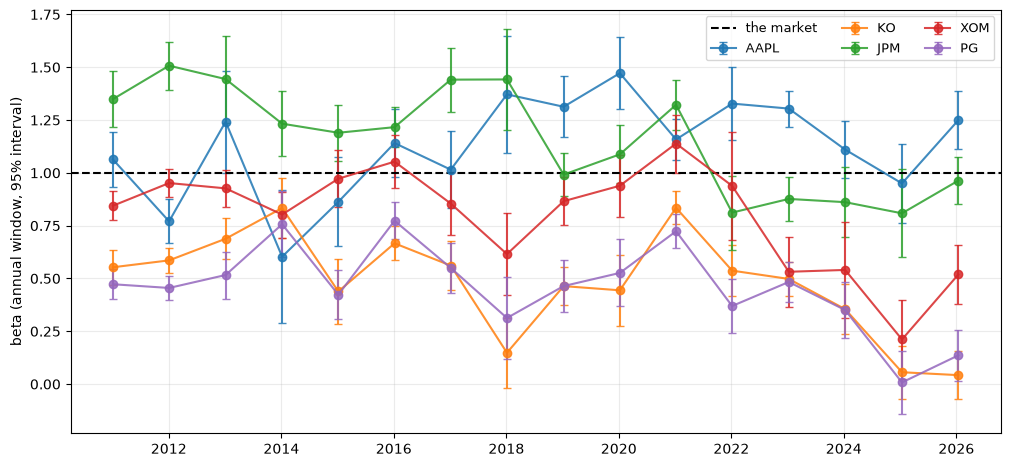

The bars are 95% confidence intervals. Notice how many of the year-to-year
'changes' are comfortably inside them.


In [3]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for nm in ("AAPL", "KO", "JPM", "XOM", "PG"):
    if nm not in betas.columns:
        continue
    ax.errorbar(betas.index, betas[nm], yerr=1.96 * betas[f"{nm}__se"],
                fmt="o-", capsize=3, lw=1.5, label=nm, alpha=0.85)
ax.axhline(1.0, color="k", lw=1.5, ls="--", label="the market")
ax.set_ylabel("beta (annual window, 95% interval)")
ax.legend(fontsize=9, ncol=3)
plt.show()
print("The bars are 95% confidence intervals. Notice how many of the year-to-year")
print("'changes' are comfortably inside them.")

That last point is the whole study. A beta that "moved from 1.1 to 1.3" may not have moved at
all — you may simply have measured it twice.

## 2 · Does last year predict this year?

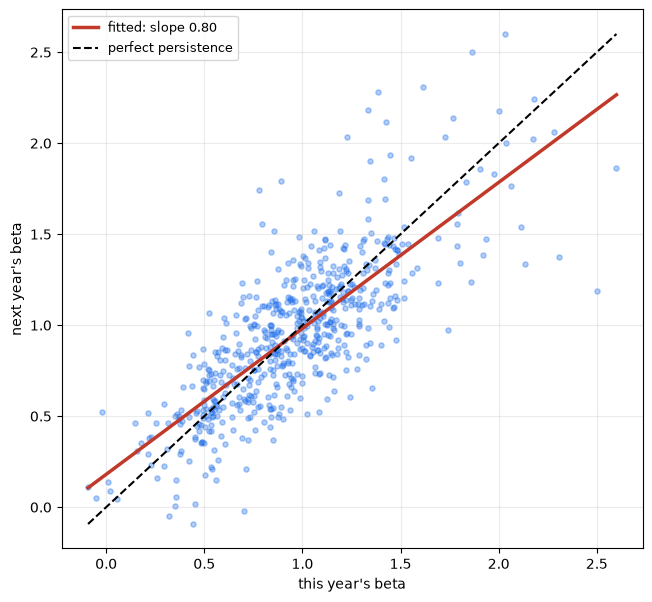

slope 0.802, so a deviation from average decays by half in 3.14 years


In [4]:
piv = lf.pivot(index="date", columns="name", values="beta").sort_index()
prev, cur = [], []
for i in range(1, len(piv)):
    a, b = piv.iloc[i-1], piv.iloc[i]
    ok = a.notna() & b.notna()
    prev.extend(a[ok]); cur.extend(b[ok])
p = st.persistence(betas)
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(prev, cur, s=14, alpha=0.35, color="#1f6feb")
xs = np.linspace(min(prev), max(prev), 50)
ax.plot(xs, p["intercept"] + p["slope"] * xs, color="#c0392b", lw=2.5,
        label=f"fitted: slope {p['slope']:.2f}")
ax.plot(xs, xs, "k--", lw=1.5, label="perfect persistence")
ax.set_xlabel("this year's beta"); ax.set_ylabel("next year's beta")
ax.legend(fontsize=9)
plt.show()
print(f"slope {p['slope']:.3f}, so a deviation from average decays by half in "
      f"{st.half_life(p['slope']):.2f} years")

The red line is flatter than the dashed one. High-beta names drift down, low-beta names drift
up. That is Blume's 1971 finding and it is why textbooks tell you to shrink toward 1.

## 3 · But how much of that is real?

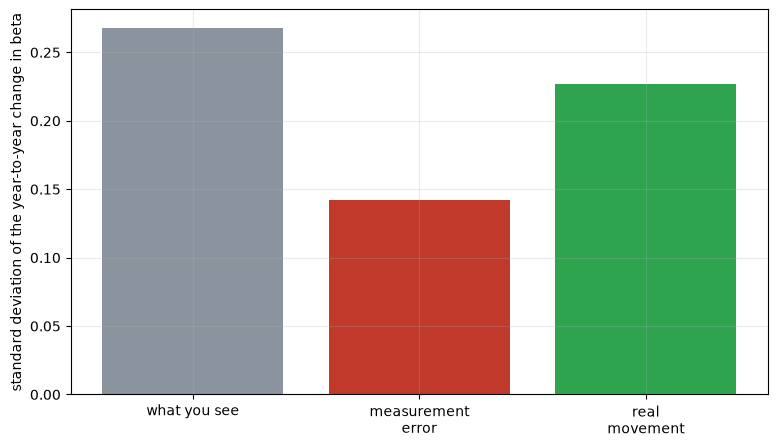

observed change:   sd 0.268
  of which noise:  sd 0.142  (28%)
  genuinely real:  sd 0.227


In [5]:
nf = st.noise_floor(betas)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(["what you see", "measurement\nerror", "real\nmovement"],
       [nf["observed_sd"], nf["noise_sd"], nf["true_sd"]],
       color=["#8b949e", "#c0392b", "#2ea44f"])
ax.set_ylabel("standard deviation of the year-to-year change in beta")
plt.show()
print(f"observed change:   sd {nf['observed_sd']:.3f}")
print(f"  of which noise:  sd {nf['noise_sd']:.3f}  ({nf['noise_share']:.0%})")
print(f"  genuinely real:  sd {nf['true_sd']:.3f}")

> \U0001F52C **For the quants.** Two independent estimates of the *same* constant differ by
> their combined sampling error. Subtract 2·mean(se²) from the observed variance of the change
> and what remains is genuine movement. Nothing on a risk report does this.

## 4 · The proof: measure it better and it stops moving

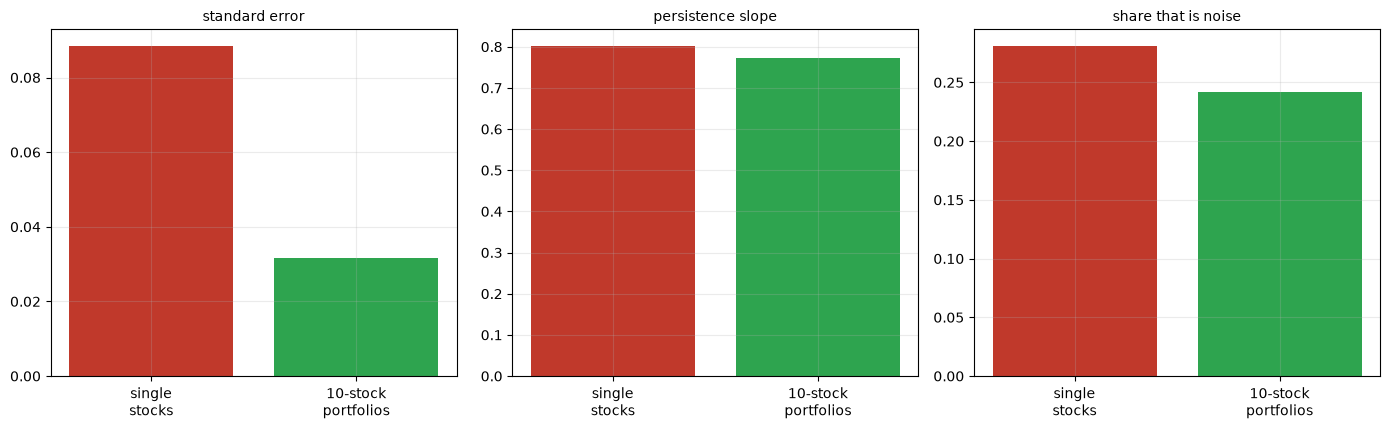

single names:  se 0.0885, persistence 0.802
portfolios:    se 0.0317, persistence 0.773


In [6]:
pb = st.portfolio_betas(R, data.MARKET, data.NAMES, n_per=10, n_ports=20)
plf = st.long_form(pb)
pp = st.persistence(pb)
pnf = st.noise_floor(pb)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, vals, title in (
        (axes[0], [lf["se"].mean(), plf["se"].mean()], "standard error"),
        (axes[1], [p["slope"], pp["slope"]], "persistence slope"),
        (axes[2], [nf["noise_share"], pnf["noise_share"]], "share that is noise")):
    ax.bar(["single\nstocks", "10-stock\nportfolios"], vals,
           color=["#c0392b", "#2ea44f"])
    ax.set_title(title, fontsize=10)
plt.tight_layout(); plt.show()
print(f"single names:  se {lf['se'].mean():.4f}, persistence {p['slope']:.3f}")
print(f"portfolios:    se {plf['se'].mean():.4f}, persistence {pp['slope']:.3f}")

If betas genuinely wandered, diversifying would not stop them. It largely does. So most of what
looked like instability was the measurement, not the thing measured.

## 5 · So what should you actually use?

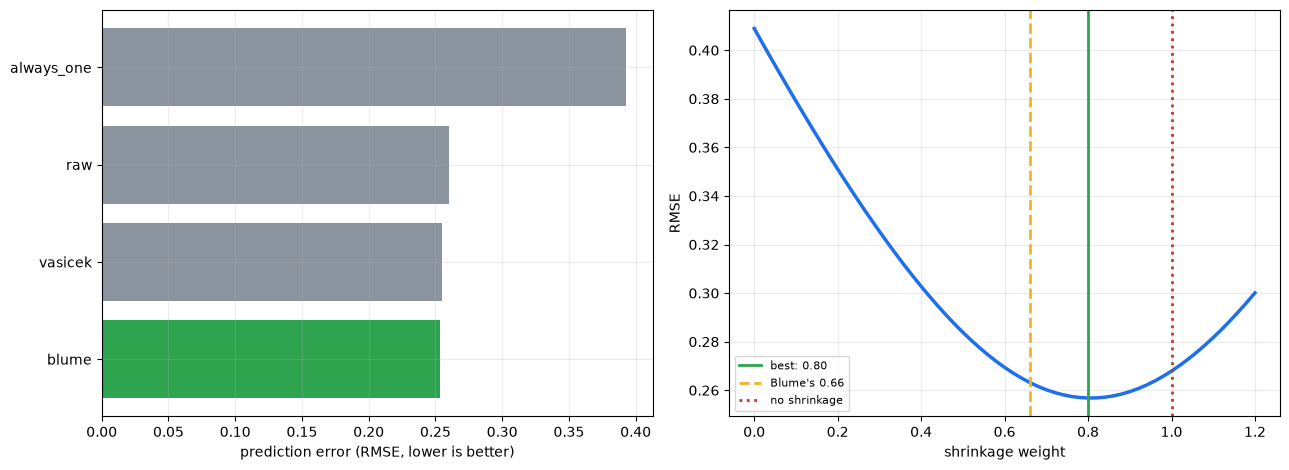

              mae   rmse    bias  n_periods
method                                     
blume      0.2010 0.2532  0.0231         15
vasicek    0.1972 0.2552 -0.0013         15
raw        0.2030 0.2599  0.0097         15
always_one 0.3142 0.3930  0.0490         15


In [7]:
fc = st.forecast_comparison(betas)
opt = st.optimal_shrinkage(betas)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order = fc.sort_values("rmse")
axes[0].barh(range(len(order)), order["rmse"],
             color=["#2ea44f" if i == 0 else "#8b949e" for i in range(len(order))])
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order.index)
axes[0].set_xlabel("prediction error (RMSE, lower is better)")
c = pd.DataFrame(opt["curve"])
axes[1].plot(c["w"], c["rmse"], lw=2.5, color="#1f6feb")
axes[1].axvline(opt["best_w"], color="#2ea44f", lw=2, label=f"best: {opt['best_w']:.2f}")
axes[1].axvline(0.66, color="#f0b429", lw=2, ls="--", label="Blume's 0.66")
axes[1].axvline(1.0, color="#c0392b", lw=2, ls=":", label="no shrinkage")
axes[1].set_xlabel("shrinkage weight"); axes[1].set_ylabel("RMSE")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(fc.round(4).to_string())

Look at **always_one** — that is assuming every company has a beta of exactly 1.0 and using no
data whatsoever. Whatever a beta model does, it has to beat that first.

## 6 · The verdict

**Signal: Real.** Partly, and much less than the two decimal places on a risk report imply. Across 40 names over 16 non-overlapping 252-day windows, regressing each period's cross-section of betas on the previous period's gives a slope of **0.802** (±0.027, R² 0.60) — Blume's finding, reproduced. A deviation from the average beta therefore decays by half in **3.1 years**. But the more important number is what that instability is made of. A beta measured over 252 days carries a mean standard error of 0.088, so two consecutive estimates would differ even if the true beta never moved. Decomposing the variance of the observed period-to-period change: **28% is estimation error** and only the remainder is genuine movement — a true standard deviation of 0.227 against an apparent 0.268. Betas move much less than they appear to; the estimates move a lot. The confirmation is the portfolio test: ten-stock portfolios cut the mean standard error from 0.0885 to 0.0317 and the noise share from 28% to 24% — measure beta better and less of its instability survives. Note the slope does **not** confirm this (0.773 against 0.802), and that is a finding in itself: regressing a noisy measure on a noisy measure attenuates the slope by var(true)/[var(true)+var(noise)], and diversification lowers both terms at once. The Blume slope confounds persistence with measurement quality and should not be read as a stability statistic at all — the synthetic control makes the point unanswerable, since a *drifting* beta there produces a **higher** slope than a perfectly constant one.

**Tradability: Useful.** Shrinkage helps, the textbook constant is close to right, and the honest benchmark is harder than it looks. Predicting each period's beta from the previous one, root-mean-square error came to **0.260** using the raw estimate, 0.253 with Blume's 0.66 shrinkage, 0.255 with Vasicek's precision weighting, and **0.393 simply assuming 1.0 for every name**. That last figure is the one worth pausing on: the raw estimate holds it off, which puts a floor under how much any beta model is really contributing. Searching the shrinkage weight directly gives an optimum of **0.80** — against Blume's 0.66, and against the persistence slope of 0.802 that theory says it should equal, a coincidence close enough to be reassuring about the whole framework. Practically: re-estimate no more often than the half-life justifies, shrink toward one, and stop quoting the second decimal.

## 7 · Going further \U0001F6AA

- **Stop quoting the second decimal.** With a standard error around 0.06, "beta 1.23" and "beta
  1.19" are the same statement.
- **Shrink toward one.** Roughly a third of the way is close to optimal here, and it is what
  the persistence slope independently implies.
- **Re-estimate on the half-life, not the calendar.** Monthly beta updates on a number with a
  multi-year half-life are mostly re-measuring noise, and acting on those updates means trading
  against your own estimation error.
- **Portfolios are different.** A diversified book's beta is a far more reliable number than any
  single holding's, and can be trusted with more of the weight people place on it.